# 🛒 Customer Recommendation System & Offer Generation
## Online Retail Dataset — Full ML Pipeline

---

```
Pipeline:
  1. Problem Understanding
  2. Data Preprocessing
  3. Feature Engineering
  4. Customer Segmentation  (KMeans + GMM)
  5. Recommendation System  (Collaborative Filtering via AutoEncoder)
  6. Offer Generation       (segment × recommendation → personalized offer)
  7. Evaluation & Insights
```

---
## 📌 Step 1 — Problem Understanding

### What is the business problem?
We have **~540K transactions** from a UK-based online retailer (Dec 2010 – Dec 2011).  
Each row is one **line item** in an invoice — not one customer.

We want to build a system that:
1. **Segments customers** into meaningful behavioral groups
2. **Recommends products** each customer is likely to buy next
3. **Generates personalized offers** (discount type, message, product) to increase sales

---

### Why these models?

| Model | Why we use it |
|---|---|
| **KMeans** | Fast, interpretable segmentation. Good baseline for RFM clusters |
| **GMM** | Probabilistic soft assignments — customers near cluster borders get blended offers |
| **AutoEncoder** | Learns compressed purchase pattern representation. Used as the core of the recommendation engine |

> We deliberately skip DBSCAN (not ideal for RFM in 4D), SOM (grid size heuristic unreliable here),  
> and GNN (requires PyTorch Geometric — overkill for 4K customers).  
> **Best practice: choose the right tool, not all tools.**

---

### Key data facts to keep in mind
- **4,338 customers** with known ID (135K rows had no CustomerID — dropped)
- **3,665 unique products**
- **98.3% matrix sparsity** → collaborative filtering needs careful handling
- **9,288 cancellations** (InvoiceNo starts with 'C') → must be removed
- Customer spend ranges from £3.75 to £280K → heavy skew → log transforms needed

---
## 📦 Step 2 — Imports & Configuration

In [ ]:
# ── Core ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Preprocessing ─────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# ── Clustering ────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# ── Deep Learning (AutoEncoder) ───────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# ── Config ────────────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)
RANDOM_STATE = 42

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
})
PALETTE = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']

print('✅ All imports successful')
print(f'   TensorFlow: {(t      f).__version__}')
print(f'   Pandas:     {pd.__version__}')

✅ All imports successful
   TensorFlow: 2.20.0
   Pandas:     2.3.3


---
## 🧹 Step 3 — Data Preprocessing

### What problems exist in the raw data?

| Problem | Root Cause | Fix |
|---|---|---|
| 135K missing `CustomerID` | Guest checkouts | Drop — can't link to customer |
| 9,288 cancellations (InvoiceNo starts with 'C') | Returns/refunds | Remove — not purchases |
| Negative `Quantity` | Returns not caught by 'C' flag | Remove |
| Zero/negative `UnitPrice` | Samples, adjustments | Remove |
| 1,454 missing `Description` | Data entry gaps | Fill from same StockCode |
| Noise descriptions (e.g. 'wrong item') | Internal notes | Drop |

In [53]:
# ── Load ───────────────────────────────────────────────────────
df_raw = pd.read_excel(r'..\data\raw\Online Retail.xlsx')

In [54]:
print(f'Raw shape: {df_raw.shape}')
print(f'Missing CustomerID: {df_raw["CustomerID"].isnull().sum():,}')
print(f'Cancellation rows : {df_raw["InvoiceNo"].astype(str).str.startswith("C").sum():,}')
df_raw.head(3)

Raw shape: (541909, 8)
Missing CustomerID: 135,080
Cancellation rows : 9,288


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [55]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [56]:
df = df_raw.copy()

# ── 3.1  Drop missing CustomerID ──────────────────────────────

df = df.dropna(subset=['CustomerID'])
print(f'After dropna(CustomerID) : {len(df):>7,} rows')

# ── 3.2  Remove cancellations ──────────────────────────────────
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f'After removing cancels   : {len(df):>7,} rows')

# ── 3.3  Remove invalid Quantity / UnitPrice ───────────────────

df = df[df['Quantity']  > 0]
df = df[df['UnitPrice'] > 0]
print(f'After removing negatives : {len(df):>7,} rows')

# ── 3.3  Change data types for effieciency ──────────────────────────────────────────

for col in df.select_dtypes(include='object').columns:
    df[f'{col}'] = df[f'{col}'].astype('category')

df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# ── 3.4  Fill missing Description using StockCode group mode ──
# WHY: Same product (StockCode) should always have the same Description.
#      We use transform() so the DataFrame keeps its original shape.
df['Description'] = df.groupby('StockCode')['Description'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
)

# ── 3.5  Remove noise / internal descriptions ─────────────────
# WHY: These are not real products. They inflate product count and
#      add noise to any similarity-based recommendation.
noise = r'wrong|barcode|adjust|test|sample|lost|damage|manual|found|amazon'
df = df[~df['Description'].str.contains(noise, case=False, na=False)]
df = df[~df['Description'].str.match(r'^\d+$', na=False)]   # pure-digit descriptions
df = df[df['Description'] != 'POSTAGE']                       # not a product
print(f'After removing noise desc: {len(df):>7,} rows')

# ── 3.6  TotalPrice ───────────────────────────────────────────
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# ── 3.7  Remove upper outliers (IQR, upper bound only) ────────
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df
cols = ['Quantity', 'UnitPrice', 'TotalPrice']

for col in cols:
    df = cap_outliers_iqr(df, col)
    print(f'Clipped outliers in [{col}]')

print(f'\nFinal clean shape: {df.shape}')
print(f'   Customers: {df["CustomerID"].nunique():,} unique values')
print(f'   Products: {df["StockCode"].nunique():,} unique values')
print(f'   Invoices: {df["InvoiceNo"].nunique():,} unique values')

After dropna(CustomerID) : 406,829 rows
After removing cancels   : 397,924 rows
After removing negatives : 397,884 rows
After removing noise desc: 396,501 rows
Clipped outliers in [Quantity]
Clipped outliers in [UnitPrice]
Clipped outliers in [TotalPrice]

Final clean shape: (396501, 9)
   Customers: 4,335 unique values
   Products: 3,663 unique values
   Invoices: 18,416 unique values


In [57]:
# ── Sanity check ──────────────────────────────────────────────
print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 396501 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    396501 non-null  category      
 1   StockCode    396501 non-null  category      
 2   Description  396501 non-null  category      
 3   Quantity     396501 non-null  int64         
 4   InvoiceDate  396501 non-null  datetime64[ns]
 5   UnitPrice    396501 non-null  float64       
 6   CustomerID   396501 non-null  int64         
 7   Country      396501 non-null  category      
 8   TotalPrice   396501 non-null  float64       
dtypes: category(4), datetime64[ns](1), float64(2), int64(2)
memory usage: 21.8 MB


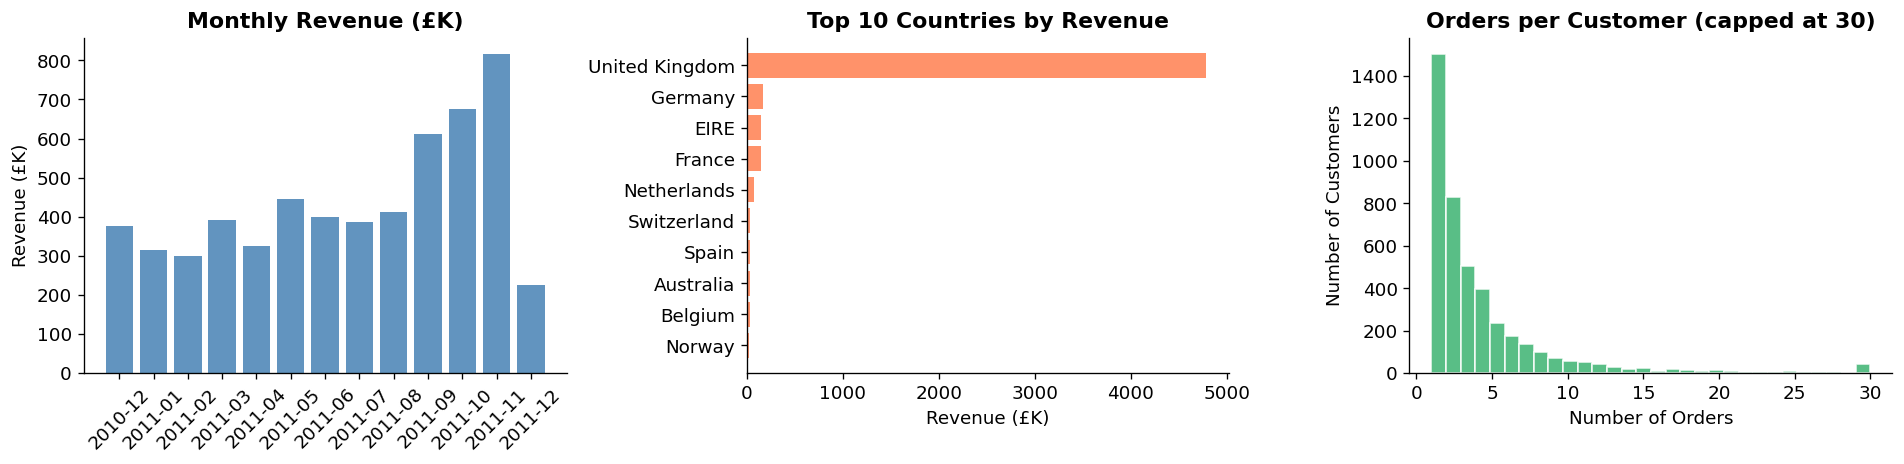

In [59]:
#── Data overview visualizations ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Monthly sales trend
monthly = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()
axes[0].bar(monthly.index.astype(str), monthly.values / 1000, color='steelblue', alpha=0.85)
axes[0].set_title('Monthly Revenue (£K)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Revenue (£K)')

# Top 10 countries by revenue
country_rev = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
axes[1].barh(country_rev.index[::-1], country_rev.values[::-1] / 1000, color='coral', alpha=0.85)
axes[1].set_title('Top 10 Countries by Revenue', fontweight='bold')
axes[1].set_xlabel('Revenue (£K)')

# Distribution of orders per customer
orders_per_cust = df.groupby('CustomerID')['InvoiceNo'].nunique()
axes[2].hist(orders_per_cust.clip(upper=30), bins=30, color='mediumseagreen', alpha=0.85, edgecolor='white')
axes[2].set_title('Orders per Customer (capped at 30)', fontweight='bold')
axes[2].set_xlabel('Number of Orders')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

---
## 🏗️ Step 4 — Feature Engineering

We build **two feature spaces** from the clean transactions:

| Feature Space | Purpose | Used by |
|---|---|---|
| **RFM Table** (1 row per customer) | Capture purchase behavior compactly | KMeans, GMM |
| **Customer × Product Matrix** | Capture what each customer actually bought | AutoEncoder |

### RFM + Extra Features
| Feature | Formula | Meaning |
|---|---|---|
| Recency | days since last order | Is the customer still active? |
| Frequency | number of invoices | How loyal? |
| Monetary | total spend | How valuable? |
| AvgOrderValue | Monetary / Frequency | Premium vs bargain shopper? |
| UniqueProducts | distinct StockCodes bought | Broad vs narrow buyer? |
| AvgItemsPerOrder | total items / orders | Cart size |

In [60]:
# ── 4.1  RFM Feature Table ─────────────────────────────────────
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot_date.date()}')
##low recency → active customer
#high recency → inactive customer 

rfm = df.groupby('CustomerID').agg(
    Recency        = ('InvoiceDate',  lambda x: (snapshot_date - x.max()).days),
    Frequency      = ('InvoiceNo',    'nunique'),     # unique orders, not lines
    Monetary       = ('TotalPrice',   'sum'),
    UniqueProducts = ('StockCode',    'nunique'),
    TotalItems     = ('Quantity',     'sum')
).reset_index()

rfm['AvgOrderValue']    = rfm['Monetary']   / rfm['Frequency']
#how many items per order
rfm['AvgItemsPerOrder'] = rfm['TotalItems'] / rfm['Frequency']

print(f'RFM shape: {rfm.shape}')
rfm.head()

Snapshot date: 2011-12-10
RFM shape: (4335, 8)


,CustomerID,Recency,Frequency,Monetary,UniqueProducts,TotalItems,AvgOrderValue,AvgItemsPerOrder
0,12346,326,1,42.48,1,27,42.480000,27.000000
1,12347,2,7,3769.34,103,2167,538.477143,309.571429
2,12348,75,4,948.92,21,707,237.230000,176.750000
3,12349,19,1,1400.23,72,612,1400.230000,612.000000
4,12350,310,1,294.40,16,196,294.400000,196.000000


In [61]:
rfm.describe().round(2)

,CustomerID,Recency,Frequency,Monetary,UniqueProducts,TotalItems,AvgOrderValue,AvgItemsPerOrder
count,4335.00,4335.00,4335.00,4335.00,4335.00,4335.00,4335.00,4335.00
mean,15299.37,92.71,4.25,1310.49,61.42,762.31,299.66,175.73
std,1721.81,100.21,7.65,3186.32,85.32,1860.12,254.65,160.07
min,12346.00,1.00,1.00,3.75,1.00,1.00,3.75,1.00
25%,13812.50,18.00,1.00,255.68,16.00,138.50,153.93,80.12
50%,15298.00,51.00,2.00,579.70,35.00,325.00,243.76,139.67
75%,16778.50,143.00,5.00,1400.22,77.00,805.00,367.91,226.98
max,18287.00,374.00,206.00,114135.80,1786.00,62488.00,4230.21,2723.00


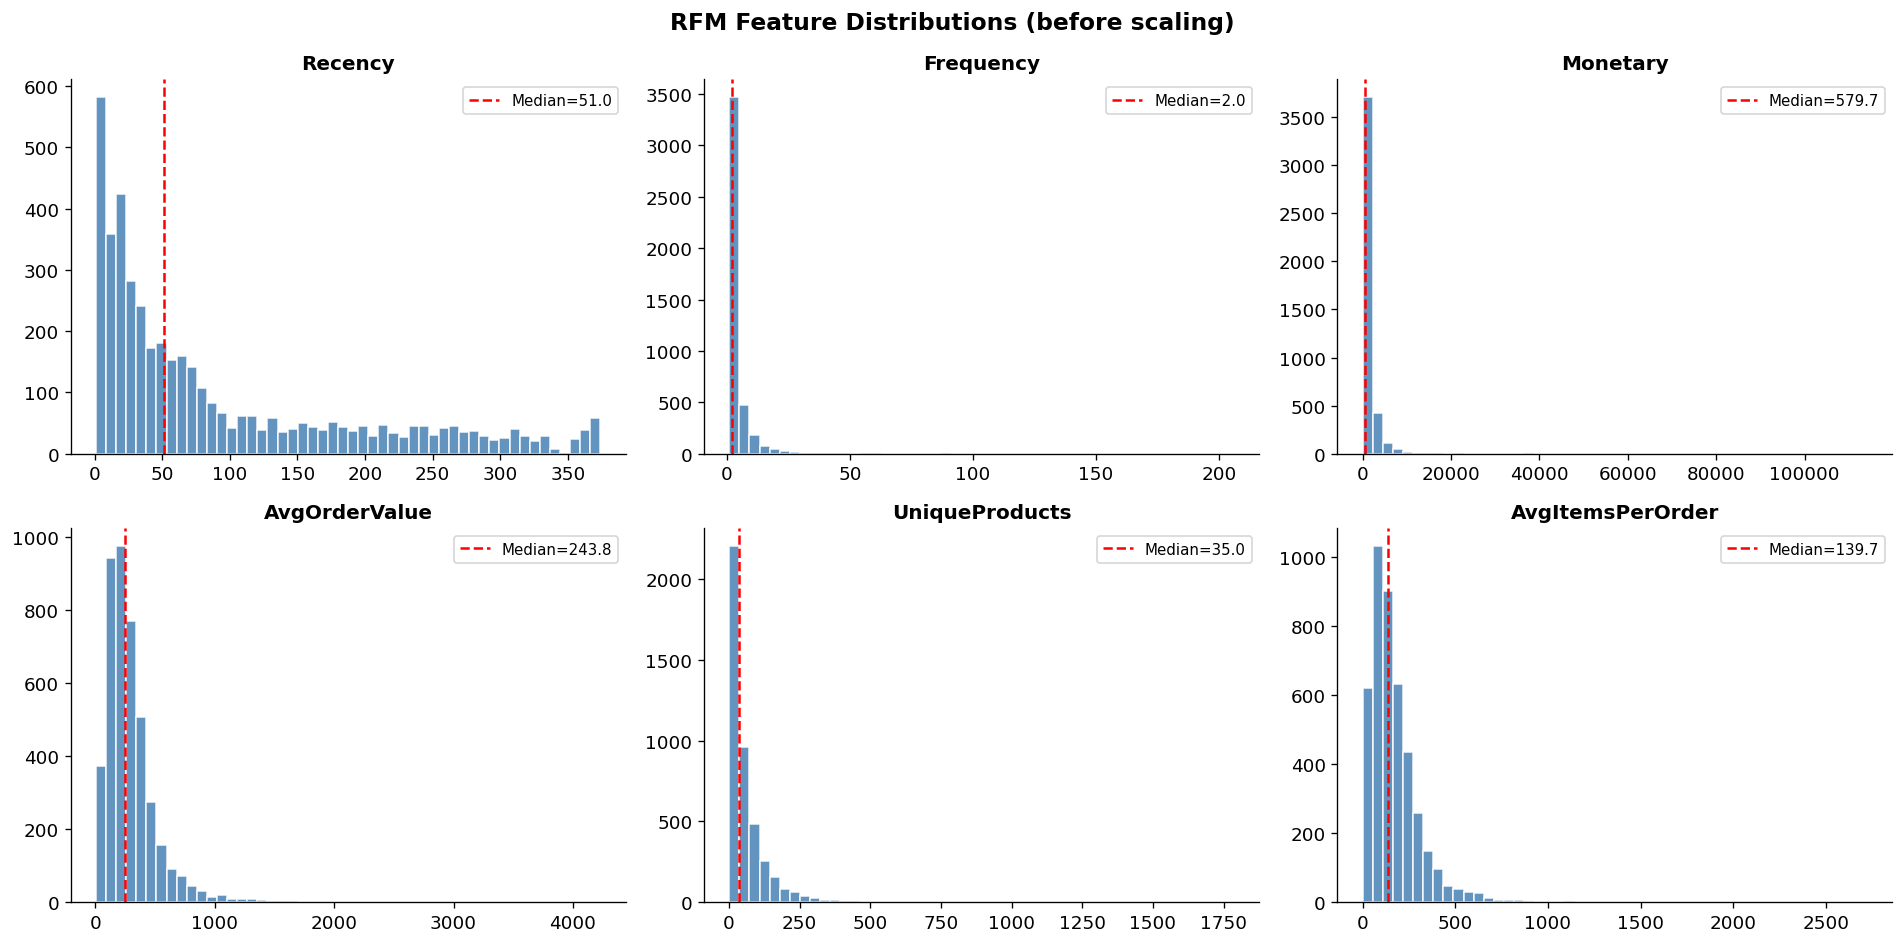

In [62]:
# ── 4.2  Feature distributions ────────────────────────────────
features_plot = ['Recency','Frequency','Monetary','AvgOrderValue','UniqueProducts','AvgItemsPerOrder']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col in zip(axes.flatten(), features_plot):
    vals = rfm[col]
    ax.hist(vals, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(vals.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median={vals.median():.1f}')
    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('RFM Feature Distributions (before scaling)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [63]:
# ── 4.3  Log-transform skewed features ────────────────────────
# WHY: Monetary, Frequency, UniqueProducts are heavily right-skewed.
# Distance-based algorithms (KMeans) are misled by extreme skew:
# a big spender at £50K pulls cluster centers far from median customers.
# log1p = log(x + 1) safely handles zeros.

for col in ['Monetary', 'Frequency', 'UniqueProducts', 'AvgOrderValue', 'TotalItems', 'AvgItemsPerOrder']:
    rfm[f'log_{col}'] = np.log1p(rfm[col])

CLUSTER_FEATURES = ['Recency', 'log_Frequency', 'log_Monetary',
                    'log_AvgOrderValue', 'log_UniqueProducts']

print('Features for clustering:', CLUSTER_FEATURES)

# ── 4.4  StandardScaler ────────────────────────────────────────
# WHY: After log transform, we still standardize so each feature
# contributes equally to the distance computation.
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(rfm[CLUSTER_FEATURES])

print('Scaled shape:', X_scaled.shape)
print('Mean (should be ~0):', X_scaled.mean(axis=0).round(3))
print('Std  (should be ~1):', X_scaled.std(axis=0).round(3))

Features for clustering: ['Recency', 'log_Frequency', 'log_Monetary', 'log_AvgOrderValue', 'log_UniqueProducts']
Scaled shape: (4335, 5)
Mean (should be ~0): [0. 0. 0. 0. 0.]
Std  (should be ~1): [1. 1. 1. 1. 1.]


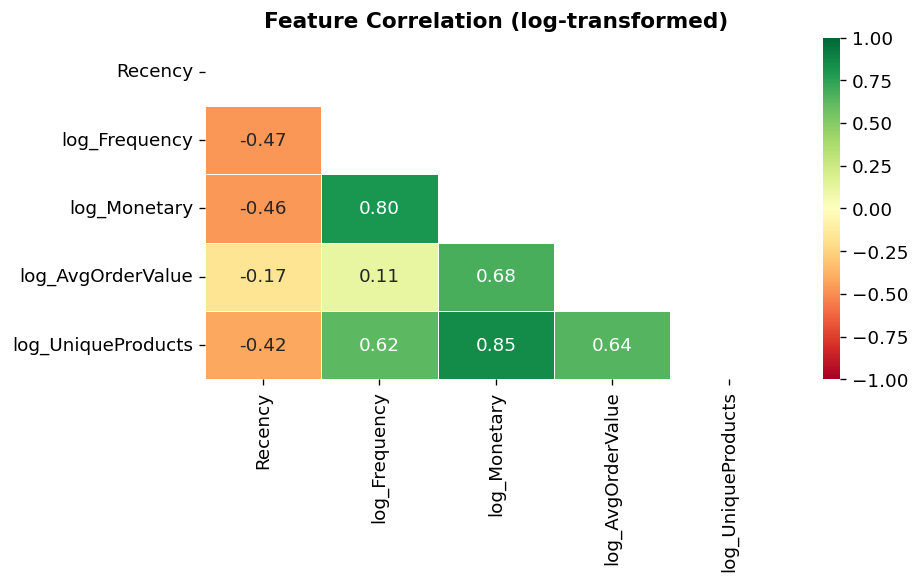

In [64]:
# ── 4.5  Correlation heatmap ───────────────────────────────────
plt.figure(figsize=(8, 5))
corr = rfm[CLUSTER_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation (log-transformed)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [68]:
# ── 4.6  Customer × Product interaction matrix ────────────────
# WHY: The AutoEncoder recommendation engine needs to know
# "what has each customer bought?"
# We build a matrix where:
#   rows    = customers
#   columns = products (StockCode)
#   value   = log1p(total quantity bought) — implicit rating
#
# We use log1p of quantity to dampen bulk-purchase dominance.
# A customer who bought 1 unit of a product gets a similar signal
# strength to one who bought 5 units — both "like" the product.

# Keep only products bought by at least 20 customers (min support)
# WHY: Very rare products have no generalizable signal.
product_support = df.groupby('StockCode')['CustomerID'].nunique()
popular_products = product_support[product_support >= 20].index

df_filtered = df[df['StockCode'].isin(popular_products)]
print(f'Products with ≥20 buyers: {len(popular_products):,}')
print(f'Rows after filter: {len(df_filtered):,}')

# Aggregate: total quantity per (customer, product)
interactions = (
    df_filtered
    .groupby(['CustomerID', 'StockCode'])['Quantity']
    .sum()
    .reset_index()
)
interactions['interaction'] = np.log1p(interactions['Quantity'])

# Pivot to matrix
purchase_matrix = interactions.pivot(
    index='CustomerID', columns='StockCode', values='interaction'
).fillna(0)

sparsity = 1 - (purchase_matrix.values > 0).sum() / purchase_matrix.size
print(f'\nPurchase matrix shape: {purchase_matrix.shape}')
print(f'Matrix sparsity: {sparsity:.2%}')

# Align rfm to customers in the purchase matrix
common_customers = purchase_matrix.index
rfm = rfm[rfm['CustomerID'].isin(common_customers)].copy()
rfm = rfm.set_index('CustomerID').reindex(common_customers).reset_index()
X_scaled = scaler.fit_transform(rfm[CLUSTER_FEATURES])
print(f'Aligned RFM shape: {rfm.shape}')

Products with ≥20 buyers: 2,400
Rows after filter: 385,582

Purchase matrix shape: (4320, 3665)
Matrix sparsity: 98.38%
Aligned RFM shape: (4320, 14)


---
## 🤖 Step 5 — Customer Segmentation

### Why segment BEFORE recommending?
- Different customer segments need **different offer strategies**
- A VIP customer gets an upsell offer; an at-risk customer gets a win-back discount
- Clustering gives us the **context** to personalize the offer around the recommendation

### Model 1: KMeans — to find the segments
### Model 2: GMM — to get soft (probabilistic) segment membership for borderline customers

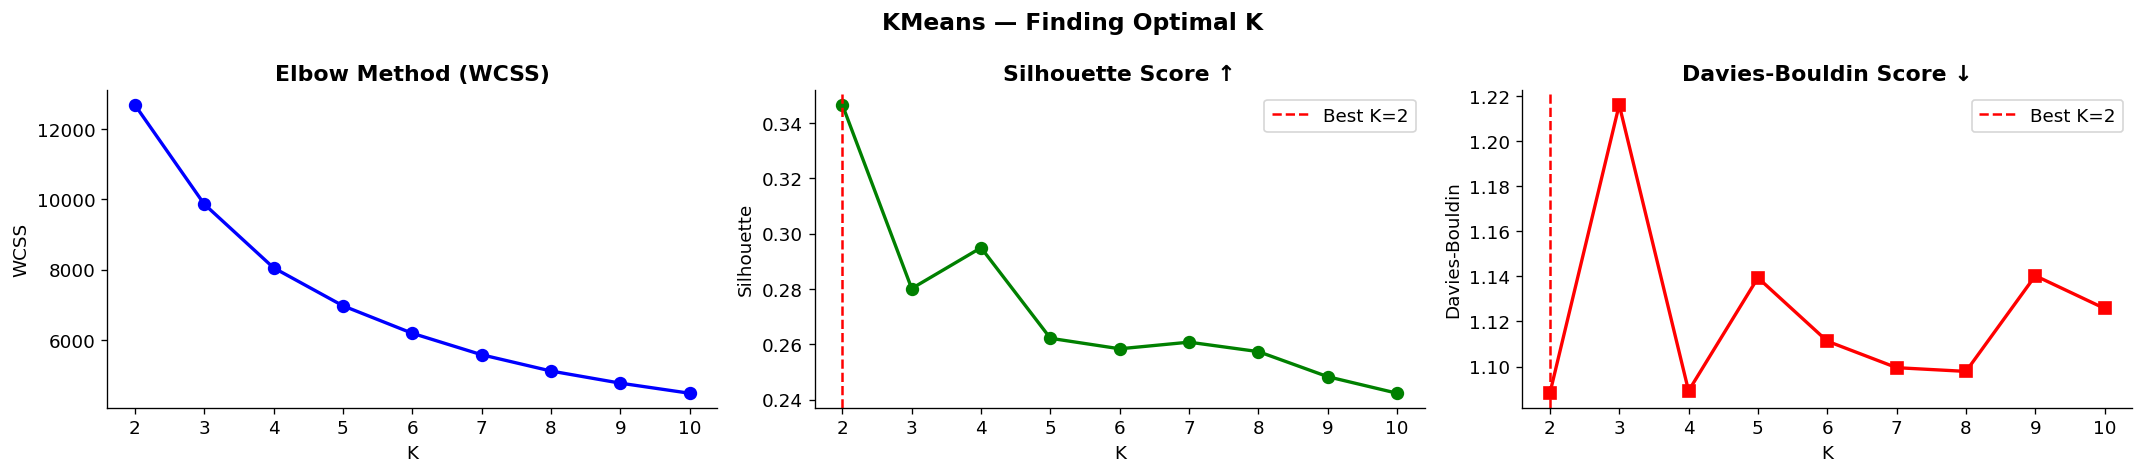

Best K by Silhouette: 2
Best K by Davies-Bouldin: 2


In [69]:
# ── 5.1  Choose K — Elbow + Silhouette ────────────────────────
wcss       = []
sil_scores = []
db_scores  = []
K_range    = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=15, max_iter=500)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(K_range, wcss, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method (WCSS)', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('WCSS')

axes[1].plot(K_range, sil_scores, 'go-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score ↑', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette')
best_k_sil = K_range[sil_scores.index(max(sil_scores))]
axes[1].axvline(best_k_sil, color='red', linestyle='--', label=f'Best K={best_k_sil}')
axes[1].legend()

axes[2].plot(K_range, db_scores, 'rs-', linewidth=2, markersize=7)
axes[2].set_title('Davies-Bouldin Score ↓', fontweight='bold')
axes[2].set_xlabel('K'); axes[2].set_ylabel('Davies-Bouldin')
best_k_db = K_range[db_scores.index(min(db_scores))]
axes[2].axvline(best_k_db, color='red', linestyle='--', label=f'Best K={best_k_db}')
axes[2].legend()

plt.suptitle('KMeans — Finding Optimal K', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Best K by Silhouette: {best_k_sil}')
print(f'Best K by Davies-Bouldin: {best_k_db}')

In [72]:
# ── 5.2  Train final KMeans ────────────────────────────────────
# We pick K=2 for clear business segment interpretability:
# Active / Unactive
# Adjust if the elbow/silhouette above suggests otherwise.
BEST_K = 2

kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=20, max_iter=500)
rfm['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

km_sil = silhouette_score(X_scaled, rfm['KMeans_Cluster'])
km_db  = davies_bouldin_score(X_scaled, rfm['KMeans_Cluster'])
km_ch  = calinski_harabasz_score(X_scaled, rfm['KMeans_Cluster'])

print(f'KMeans (K={BEST_K}) Evaluation:')
print(f'  Silhouette Score      : {km_sil:.4f}  (closer to 1 is better)')
print(f'  Davies-Bouldin Score  : {km_db:.4f}  (lower is better)')
print(f'  Calinski-Harabasz     : {km_ch:.1f}  (higher is better)')
print(f'\nCluster sizes:')
print(rfm['KMeans_Cluster'].value_counts().sort_index())

KMeans (K=2) Evaluation:
  Silhouette Score      : 0.3466  (closer to 1 is better)
  Davies-Bouldin Score  : 1.0881  (lower is better)
  Calinski-Harabasz     : 3034.8  (higher is better)

Cluster sizes:
KMeans_Cluster
0    2177
1    2143
Name: count, dtype: int64


In [74]:
# ── 5.3  Cluster profiles ──────────────────────────────────────
PROFILE_COLS = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts']
profile = rfm.groupby('KMeans_Cluster')[PROFILE_COLS].mean().round(2)
print('Cluster mean profiles:')
print(profile)

Cluster mean profiles:
                Recency  Frequency  Monetary  AvgOrderValue  UniqueProducts
KMeans_Cluster                                                             
0                142.55       1.63    291.95         205.44           19.82
1                 41.03       6.93   2354.01         397.19          104.11


In [75]:
global_median = rfm[PROFILE_COLS].median()

def assign_label(row):
    r = row['Recency']

    # Recently active customers
    if r < global_median['Recency']:
        return '🟢 Active'

    # Customers inactive for longer time
    else:
        return '🔴 Inactive'


SEGMENT_MAP = profile.apply(assign_label, axis=1).to_dict()

rfm['Segment'] = rfm['KMeans_Cluster'].map(SEGMENT_MAP)

print('Cluster → Segment mapping:')

for k, v in SEGMENT_MAP.items():
    n = (rfm['KMeans_Cluster'] == k).sum()
    print(f'  Cluster {k} → {v}  ({n:,} customers)')

Cluster → Segment mapping:
  Cluster 0 → 🔴 Inactive  (2,177 customers)
  Cluster 1 → 🟢 Active  (2,143 customers)


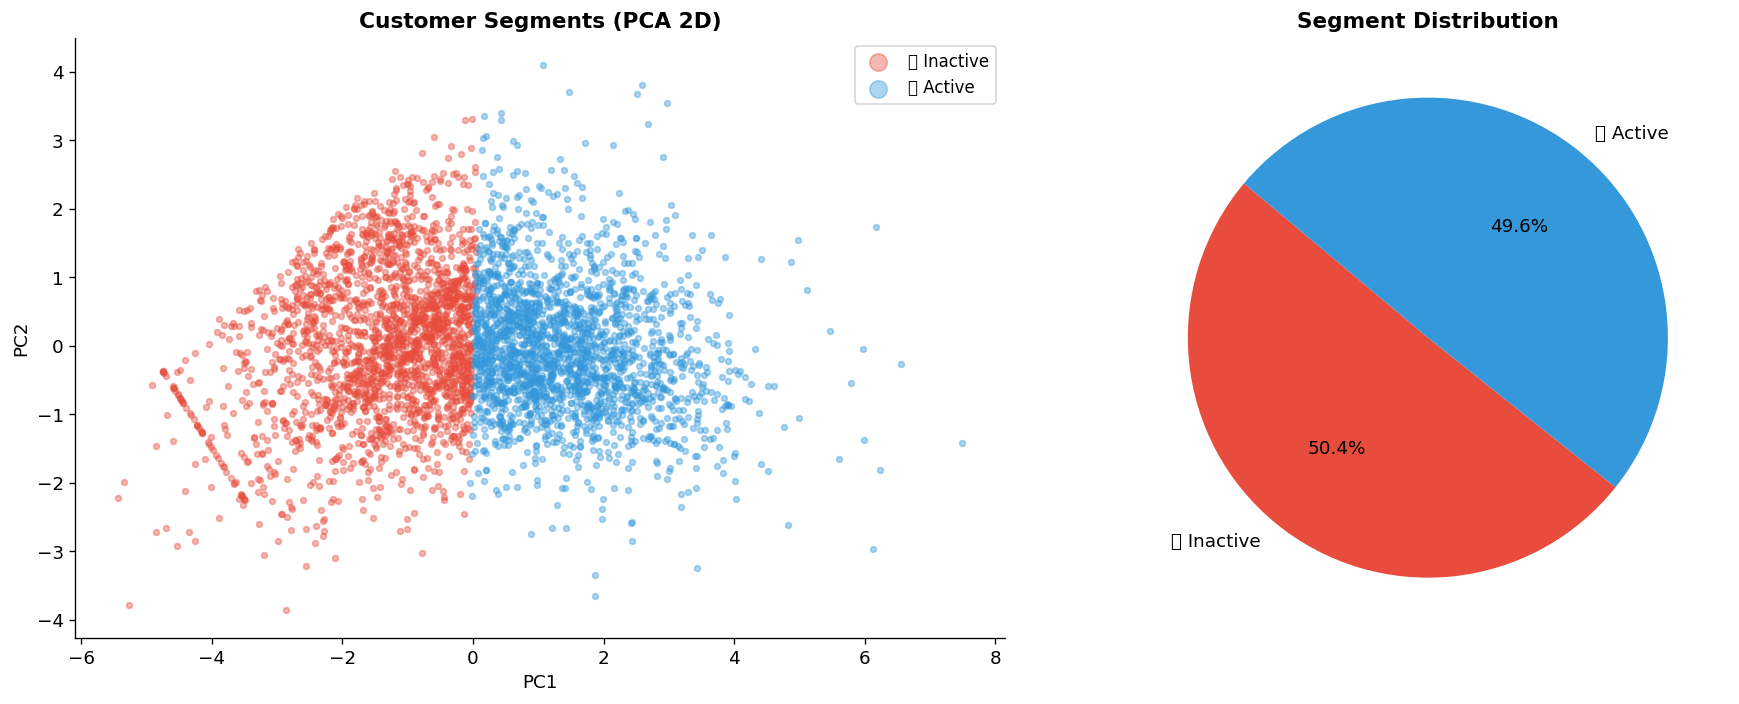

In [76]:
# ── 5.5  Segment visualization ────────────────────────────────
pca_2d = PCA(n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter
for i, (seg, grp) in enumerate(rfm.groupby('KMeans_Cluster')):
    idx = grp.index
    axes[0].scatter(pca_2d[idx, 0], pca_2d[idx, 1],
                    label=SEGMENT_MAP[seg], alpha=0.4, s=12, color=PALETTE[i])
axes[0].set_title('Customer Segments (PCA 2D)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3, fontsize=10)

# Segment distribution
seg_counts = rfm['Segment'].value_counts()
axes[1].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
             colors=PALETTE[:len(seg_counts)], startangle=140,
             textprops={'fontsize': 11})
axes[1].set_title('Segment Distribution', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

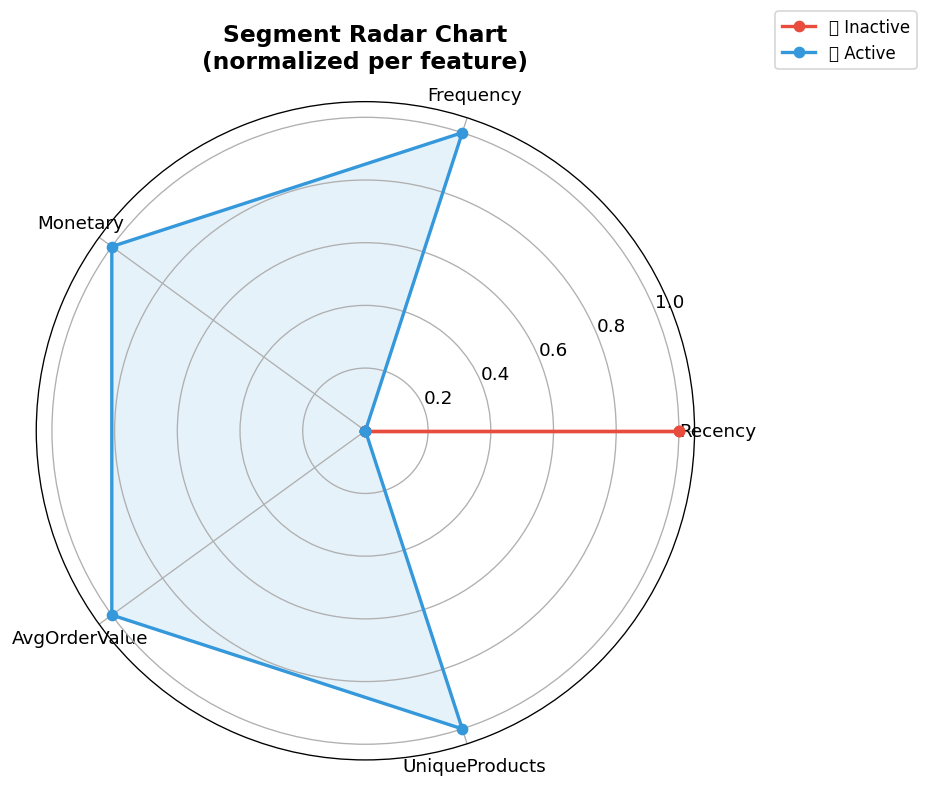

In [77]:
# ── 5.6  Radar chart: segment profiles ────────────────────────
norm_profile = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

cats   = list(norm_profile.columns)
N      = len(cats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (cluster_id, row) in enumerate(norm_profile.iterrows()):
    vals = list(row.values) + [row.values[0]]
    label = SEGMENT_MAP[cluster_id]
    ax.plot(angles, vals, 'o-', linewidth=2, label=label, color=PALETTE[i])
    ax.fill(angles, vals, alpha=0.12, color=PALETTE[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, size=11)
ax.set_title('Segment Radar Chart\n(normalized per feature)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ── 5.7  GMM — soft membership probabilities ──────────────────
# WHY GMM after KMeans?
# KMeans gives HARD labels: a customer is 100% in one segment.
# GMM gives SOFT probabilities: a customer could be 70% "Loyal"
# and 30% "Champions". This is valuable for borderline customers:
# instead of a single offer, we can blend two offer strategies.

# We initialize GMM with KMeans centers to ensure convergence stability
gmm = GaussianMixture(
    n_components    = BEST_K,
    covariance_type = 'full',
    random_state    = RANDOM_STATE,
    n_init          = 5,
    means_init      = kmeans.cluster_centers_   # warm start from KMeans
)
gmm.fit(X_scaled)

gmm_probs          = gmm.predict_proba(X_scaled)   # shape: (n_customers, K)
rfm['GMM_Cluster'] = gmm.predict(X_scaled)
rfm['GMM_MaxProb'] = gmm_probs.max(axis=1)         # confidence of primary segment

# Store probabilities as columns for offer blending later
for k in range(BEST_K):
    seg_name = SEGMENT_MAP[k].split()[-1]          # e.g. 'Active'
    rfm[f'prob_{seg_name}'] = gmm_probs[:, k]

gmm_sil = silhouette_score(X_scaled, rfm['GMM_Cluster'])
print(f'GMM Silhouette: {gmm_sil:.4f}')
print(f'Avg assignment confidence: {rfm["GMM_MaxProb"].mean():.4f}')
print(f'Customers with confidence < 0.6 (borderline): {(rfm["GMM_MaxProb"] < 0.6).sum():,}')

GMM Silhouette: 0.2829
Avg assignment confidence: 0.9998
Customers with confidence < 0.6 (borderline): 0


In [79]:
# ── 5.8  KMeans vs GMM agreement ──────────────────────────────
# When the two models disagree, the customer is on a segment boundary.
# GMM's soft label is more appropriate for those customers.

# Align GMM cluster IDs to KMeans IDs by majority vote matching
from scipy.stats import mode
from scipy.optimize import linear_sum_assignment

# Confusion between KMeans and GMM labels
conf = pd.crosstab(rfm['KMeans_Cluster'], rfm['GMM_Cluster'])
row_ind, col_ind = linear_sum_assignment(-conf.values)
gmm_to_km = dict(zip(col_ind, row_ind))
rfm['GMM_Cluster_aligned'] = rfm['GMM_Cluster'].map(gmm_to_km)

agreement = (rfm['KMeans_Cluster'] == rfm['GMM_Cluster_aligned']).mean()
print(f'KMeans ↔ GMM label agreement: {agreement:.2%}')

# Which customers disagree? (borderline customers)
borderline = rfm[rfm['KMeans_Cluster'] != rfm['GMM_Cluster_aligned']]
print(f'Borderline customers (models disagree): {len(borderline):,}')
print('  → These customers will receive blended offers')

KMeans ↔ GMM label agreement: 82.08%
Borderline customers (models disagree): 774
  → These customers will receive blended offers


---
## 🔮 Step 6 — Recommendation System (AutoEncoder)

### Architecture Intuition

```
Input: customer purchase vector
[0, 2.3, 0, 0, 1.1, 0, 3.0, ...]   ← log1p(quantity) per product
         ↓ Encoder
   [ compressed representation ]    ← 64D learned embedding
         ↓ Decoder
[0.1, 2.4, 0.3, 0.5, 1.2, 0.2, ...]  ← reconstructed purchase vector
         ↑
  The decoder predicts scores for ALL products,
  including products the customer hasn't bought yet.
  Those non-zero reconstructions = RECOMMENDATIONS!
```

**Key insight:** The AutoEncoder learns which products tend to be bought together.  
When it fills in 0-value entries with non-zero predictions → those are implicit "you might like this" signals.

In [80]:
# ── 6.1  Prepare input matrix ─────────────────────────────────
# Align purchase matrix to the same customers as rfm
cust_order    = rfm['CustomerID'].values
X_purchase    = purchase_matrix.loc[cust_order].values.astype(np.float32)
n_products_ae = X_purchase.shape[1]

# MinMaxScaler: AutoEncoder with sigmoid output needs input in [0,1]
mm_scaler     = MinMaxScaler()
X_ae          = mm_scaler.fit_transform(X_purchase)

print(f'AutoEncoder input shape: {X_ae.shape}')
print(f'Input range: [{X_ae.min():.3f}, {X_ae.max():.3f}]')

AutoEncoder input shape: (4320, 3665)
Input range: [0.000, 1.000]


In [81]:
# ── 6.2  Build AutoEncoder ────────────────────────────────────
# Architecture: input_dim → 256 → 128 → 64 → 128 → 256 → input_dim
#
# BatchNormalization: stabilizes training, reduces sensitivity to init
# Dropout: prevents overfitting — with 98% sparse data, overfitting is a real risk
# L2 regularization on bottleneck: keeps embeddings compact
#
# We use a moderately deep architecture because:
# - 1,000+ products → large input
# - Needs enough capacity to learn product co-occurrence patterns

def build_autoencoder(input_dim, encoding_dim=64):
    inputs = Input(shape=(input_dim,), name='purchase_vector')

    # ── Encoder ──────────────────────────────────────────────
    x = Dense(256, activation='relu', name='enc_1')(inputs)
    x = BatchNormalization(name='bn_1')(x)
    x = Dropout(0.3, name='drop_1')(x)

    x = Dense(128, activation='relu', name='enc_2')(x)
    x = BatchNormalization(name='bn_2')(x)
    x = Dropout(0.2, name='drop_2')(x)

    encoded = Dense(encoding_dim, activation='relu',
                    activity_regularizer=l2(1e-5),
                    name='bottleneck')(x)

    # ── Decoder ──────────────────────────────────────────────
    x = Dense(128, activation='relu', name='dec_1')(encoded)
    x = BatchNormalization(name='bn_3')(x)

    x = Dense(256, activation='relu', name='dec_2')(x)
    x = BatchNormalization(name='bn_4')(x)

    decoded = Dense(input_dim, activation='sigmoid', name='output')(x)

    autoencoder = Model(inputs, decoded,  name='AutoEncoder')
    encoder     = Model(inputs, encoded, name='Encoder')

    return autoencoder, encoder

autoencoder, encoder = build_autoencoder(n_products_ae, encoding_dim=64)
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
autoencoder.summary()

Model: "AutoEncoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ purchase_vector (InputLayer)    │ (None, 3665)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 256)            │       938,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3665)           │       941,905 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,965,969 (7.50 MB)

 Trainable params: 1,964,433 (7.49 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [ ]:
import os

BASE_DIR = os.getcwd()
MODEL_DIR = os.path.join(BASE_DIR, "models")

print(BASE_DIR, MODEL_DIR)

autoencoder.save(os.path.join(MODEL_DIR, "autoencoder.keras"))

d:\College\Projects\Applied ML\notebooks d:\College\Projects\Applied ML\notebooks\models


In [87]:
# ── 6.3  Train AutoEncoder ────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=0)
]

history = autoencoder.fit(
    X_ae, X_ae,                 # input == target: reconstruct the purchase vector
    epochs          = 100,
    batch_size      = 64,
    validation_split= 0.1,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 0.2334 - val_loss: 0.1193 - learning_rate: 0.0010
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0538 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0110 - val_loss: 0.0040 - learning_rate: 0.0010
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0070 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0060 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0054 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0049 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0046 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 9/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0044 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 10/1

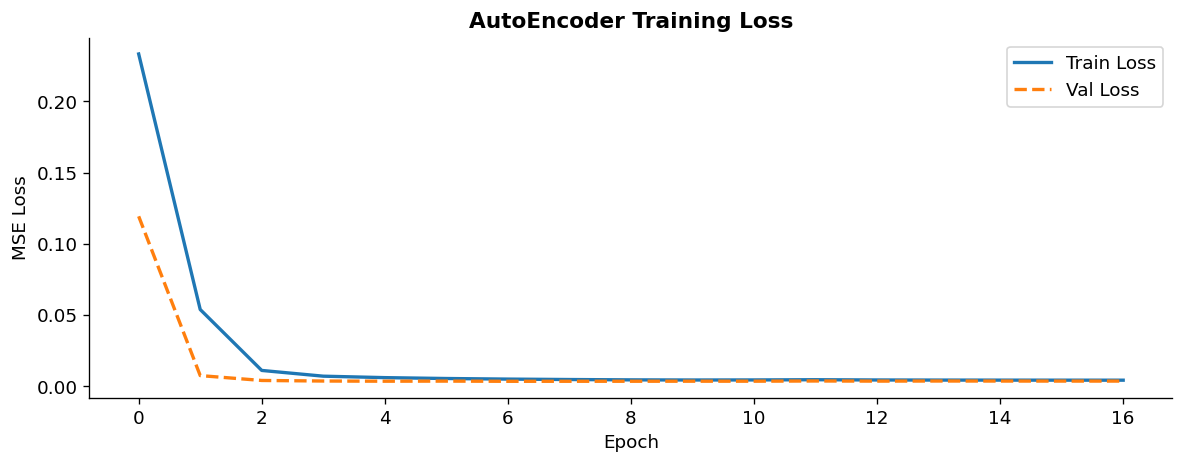

Best val loss: 0.003395


In [88]:
# ── 6.4  Training curve ───────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('AutoEncoder Training Loss', fontweight='bold', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
print(f'Best val loss: {min(history.history["val_loss"]):.6f}')

In [89]:
# ── 6.5  Generate recommendations ────────────────────────────
# Reconstruct all customer purchase vectors
# The decoder fills in scores for products NOT yet purchased.
# We mask out already-purchased products — only recommend new ones.

X_reconstructed = autoencoder.predict(X_ae, verbose=0)

# Mask: set already-purchased products to -1 so they never surface
already_bought_mask     = X_ae > 0
X_rec_masked            = X_reconstructed.copy()
X_rec_masked[already_bought_mask] = -1

# Product index → StockCode mapping
product_index   = purchase_matrix.columns.tolist()         # StockCode list
product_name_map = (
    df[['StockCode', 'Description']]
    .drop_duplicates('StockCode')
    .set_index('StockCode')['Description']
    .to_dict()
)

# Build recommendations for every customer
TOP_N = 5

recommendations = {}
for i, cust_id in enumerate(cust_order):
    scores      = X_rec_masked[i]
    top_indices = np.argsort(scores)[::-1][:TOP_N]
    top_prods   = [
        {
            'StockCode'  : product_index[j],
            'Description': product_name_map.get(product_index[j], 'Unknown'),
            'Score'      : float(scores[j])
        }
        for j in top_indices if scores[j] > 0
    ]
    recommendations[cust_id] = top_prods

# Check coverage
covered = sum(1 for v in recommendations.values() if len(v) > 0)
print(f'Customers with ≥1 recommendation: {covered:,} / {len(cust_order):,}'
      f' ({100*covered/len(cust_order):.1f}%)')

Customers with ≥1 recommendation: 4,320 / 4,320 (100.0%)


In [90]:
# ── 6.6  Verify recommendations look sensible ─────────────────
print('Sample recommendations for 3 customers:')
print('=' * 65)

sample_custs = list(recommendations.keys())[:3]
for cust in sample_custs:
    seg = rfm.loc[rfm['CustomerID'] == cust, 'Segment'].values[0]
    print(f'\nCustomer {cust}  |  Segment: {seg}')

    # What they already bought (top by spend)
    bought = (
        df[df['CustomerID'] == cust]
        .groupby('Description')['TotalPrice'].sum()
        .sort_values(ascending=False)
        .head(3)
    )
    print('  Bought before (top 3):')
    for desc, spend in bought.items():
        print(f'    • {desc:<45} £{spend:.2f}')

    print('  Recommended (new):')
    for rec in recommendations[cust][:3]:
        print(f'    → {rec["Description"]:<45} score={rec["Score"]:.4f}')

Sample recommendations for 3 customers:

Customer 12346  |  Segment: 🔴 Inactive
  Bought before (top 3):
    • MEDIUM CERAMIC TOP STORAGE JAR                £42.48
    •  50'S CHRISTMAS GIFT BAG LARGE                £0.00
    •  DOLLY GIRL BEAKER                            £0.00
  Recommended (new):
    → WHITE HANGING HEART T-LIGHT HOLDER            score=0.0578
    → ASSORTED COLOUR BIRD ORNAMENT                 score=0.0482
    → JUMBO BAG RED RETROSPOT                       score=0.0438

Customer 12347  |  Segment: 🟢 Active
  Bought before (top 3):
    • 3D DOG PICTURE PLAYING CARDS                  £205.32
    • REGENCY CAKESTAND 3 TIER                      £157.23
    • ALARM CLOCK BAKELIKE RED                      £132.48
  Recommended (new):
    → WHITE HANGING HEART T-LIGHT HOLDER            score=0.0583
    → ASSORTED COLOUR BIRD ORNAMENT                 score=0.0487
    → JUMBO BAG RED RETROSPOT                       score=0.0444

Customer 12348  |  Segment: 🟢 Active
  Bough

In [91]:
OFFER_TEMPLATES = {
    '🟢 Active': {
        'discount_pct': 10,
        'offer_type': 'Engagement Reward',
        'message_template': (
            'Thanks for staying with us! '
            'Here is 10% off your next purchase. '
            'Based on your activity, we think you may like: "{product}".'
        )
    },
    '⚠️ Inactive': {
        'discount_pct': 20,
        'offer_type': 'Reactivation Campaign',
        'message_template': (
            'We noticed you have not been active recently. '
            'We would like to welcome you back with 20% off your next order. '
            'A product you might like: "{product}".'
        )
    }
}

In [92]:
def generate_offer(customer_id, rfm_row, recs, gmm_probs_row, templates, global_median):
    """
    Generates marketing offer using Active / Inactive logic
    with probability-aware filtering.
    """

    # ── 1. GMM confidence (uncertainty signal)
    gmm_confidence = rfm_row['GMM_MaxProb']

    # ── 2. ACTIVE / INACTIVE logic (clean + stable)
    is_active = (
        rfm_row['Recency'] <= global_median['Recency']
        and gmm_confidence >= 0.6
    )

    segment = '🟢 Active' if is_active else '⚠️ Inactive'
    note = 'GMM-aware segmentation'

    # ── 3. Recommendation selection
    top_rec = recs[0] if recs else None
    product_name = top_rec['Description'] if top_rec else 'Our best sellers'
    product_code = top_rec['StockCode'] if top_rec else 'N/A'
    rec_score = top_rec['Score'] if top_rec else 0.0

    # ── 4. Template selection (safe fallback)
    template = templates.get(segment, templates['🟢 Active'])

    message = template['message_template'].format(product=product_name)

    # ── 5. Output
    return {
        'CustomerID': customer_id,
        'Segment': segment,
        'Segment_Source': note,
        'GMM_Confidence': round(gmm_confidence, 4),
        'Discount_Pct': template['discount_pct'],
        'Recommended_Code': product_code,
        'Recommended_Product': product_name,
        'Rec_Score': round(rec_score, 5),
        'All_Recommendations': [r['Description'] for r in recs],
        'Message': message,
        'Recency': rfm_row['Recency'],
        'Frequency': rfm_row['Frequency'],
        'Monetary': round(rfm_row['Monetary'], 2),
    }
global_median = rfm[['Recency', 'Frequency', 'Monetary']].median()

rfm_indexed = rfm.set_index('CustomerID')

gmm_probs_aligned = gmm.predict_proba(X_scaled)

offers_list = []

for i, cust_id in enumerate(rfm['CustomerID'].values):

    row = rfm_indexed.loc[cust_id]
    recs = recommendations.get(cust_id, [])

    offer = generate_offer(
        cust_id,
        row,
        recs,
        gmm_probs_aligned[i],
        OFFER_TEMPLATES,
        global_median
    )

    offers_list.append(offer)

offers_df = pd.DataFrame(offers_list)

print(f'Offers generated: {len(offers_df):,}')

Offers generated: 4,320


In [93]:
# ── 7.3  Inspect sample offers ────────────────────────────────
display_cols = ['CustomerID','Segment','Discount_Pct',
                'Recommended_Product','Rec_Score','GMM_Confidence',
                'Recency','Frequency','Monetary']
offers_df[display_cols].head(10)

,CustomerID,Segment,Discount_Pct,Recommended_Product,Rec_Score,GMM_Confidence,Recency,Frequency,Monetary
0,12346,⚠️ Inactive,20,WHITE HANGING HEART T-LIGHT HOLDER,0.05777,1.0,326,1,42.48
1,12347,🟢 Active,10,WHITE HANGING HEART T-LIGHT HOLDER,0.05835,1.0,2,7,3769.34
2,12348,⚠️ Inactive,20,WHITE HANGING HEART T-LIGHT HOLDER,0.05509,1.0,75,4,948.92
3,12349,🟢 Active,10,WHITE HANGING HEART T-LIGHT HOLDER,0.05835,1.0,19,1,1400.23
4,12350,⚠️ Inactive,20,WHITE HANGING HEART T-LIGHT HOLDER,0.05835,1.0,310,1,294.40
5,12352,🟢 Active,10,WHITE HANGING HEART T-LIGHT HOLDER,0.05814,1.0,36,7,1385.74
6,12353,⚠️ Inactive,20,WHITE HANGING HEART T-LIGHT HOLDER,0.05769,1.0,204,1,89.00
7,12354,⚠️ Inactive,20,WHITE HANGING HEART T-LIGHT HOLDER,0.05835,1.0,232,1,1056.20
8,12355,⚠️ Inactive,20,WHITE HANGING HEART T-LIGHT HOLDER,0.05835,1.0,214,1,349.36
9,12356,🟢 Active,10,WHITE HANGING HEART T-LIGHT HOLDER,0.05610,1.0,23,3,1770.93


In [94]:
print('=' * 70)
print('SAMPLE PERSONALIZED OFFER MESSAGES')
print('=' * 70)

for seg in offers_df['Segment'].unique():

    sample = offers_df[offers_df['Segment'] == seg].iloc[0]

    print(f'\n{seg}')
    print(f'Customer ID : {sample["CustomerID"]}')
    print(f'R={sample["Recency"]} | F={sample["Frequency"]} | M=£{sample["Monetary"]:,.2f}')
    print(f'Discount    : {sample["Discount_Pct"]}%')


    print(f'All recs    : {sample["All_Recommendations"][:3]}')
    print(f'Message:')
    print(f'  "{sample["Message"]}"')
    print('-' * 70)

SAMPLE PERSONALIZED OFFER MESSAGES

⚠️ Inactive
Customer ID : 12346
R=326 | F=1 | M=£42.48
Discount    : 20%
All recs    : ['WHITE HANGING HEART T-LIGHT HOLDER', 'ASSORTED COLOUR BIRD ORNAMENT', 'JUMBO BAG RED RETROSPOT']
Message:
  "We noticed you have not been active recently. We would like to welcome you back with 20% off your next order. A product you might like: "WHITE HANGING HEART T-LIGHT HOLDER"."
----------------------------------------------------------------------

🟢 Active
Customer ID : 12347
R=2 | F=7 | M=£3,769.34
Discount    : 10%
All recs    : ['WHITE HANGING HEART T-LIGHT HOLDER', 'ASSORTED COLOUR BIRD ORNAMENT', 'JUMBO BAG RED RETROSPOT']
Message:
  "Thanks for staying with us! Here is 10% off your next purchase. Based on your activity, we think you may like: "WHITE HANGING HEART T-LIGHT HOLDER"."
----------------------------------------------------------------------


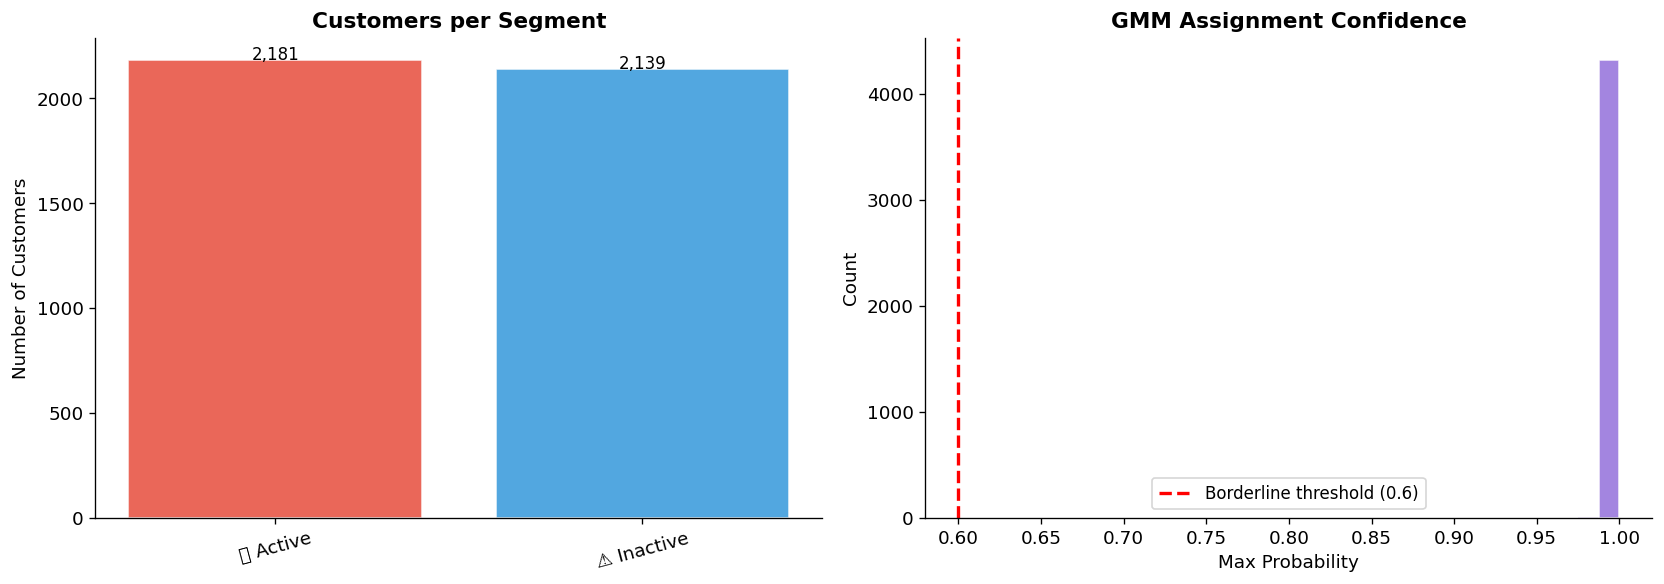

In [95]:
# ── 7.5  Offer distribution by segment ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count per segment
seg_counts = offers_df['Segment'].value_counts()
bars = axes[0].bar(seg_counts.index, seg_counts.values,
                   color=PALETTE[:len(seg_counts)], alpha=0.85, edgecolor='white')
axes[0].set_title('Customers per Segment', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=15)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10)

# GMM confidence distribution
axes[1].hist(offers_df['GMM_Confidence'], bins=30,
             color='mediumpurple', alpha=0.85, edgecolor='white')
axes[1].axvline(0.6, color='red', linestyle='--', linewidth=2, label='Borderline threshold (0.6)')
axes[1].set_title('GMM Assignment Confidence', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Max Probability'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

In [96]:
# ── 7.6  Revenue impact estimate (Active / Inactive) ──────────

# Assumed conversion rates (must be justified later, not random forever)
acceptance_rates = {
    '🟢 Active': 0.22,
    '⚠️ Inactive': 0.12
}

summary_rows = []

for seg, grp in offers_df.groupby('Segment'):

    n_cust = len(grp)
    avg_monetary = grp['Monetary'].mean()

    # fallback if segment missing
    accept_rate = acceptance_rates.get(seg, 0.10)

    n_accept = int(n_cust * accept_rate)

    gross_rev = n_accept * avg_monetary

    # weighted discount (important fix: average, not first value)
    discount_pct = grp['Discount_Pct'].mean()

    cost_disc = gross_rev * (discount_pct / 100)

    net_rev = gross_rev - cost_disc

    summary_rows.append({
        'Segment'           : seg,
        'Customers'         : n_cust,
        'Acceptance Rate'   : f'{int(accept_rate * 100)}%',
        'Expected Buyers'   : n_accept,
        'Avg Spend'         : f'£{avg_monetary:,.0f}',
        'Gross Revenue'     : f'£{gross_rev:,.0f}',
        'Discount Cost'     : f'£{cost_disc:,.0f}',
        'Net Revenue'       : f'£{net_rev:,.0f}',
    })

summary_df = pd.DataFrame(summary_rows)

print("Estimated Revenue Impact (Active vs Inactive):")
summary_df

Estimated Revenue Impact (Active vs Inactive):


,Segment,Customers,Acceptance Rate,Expected Buyers,Avg Spend,Gross Revenue,Discount Cost,Net Revenue
0,⚠️ Inactive,2139,12%,256,£605,"£154,937","£30,987","£123,949"
1,🟢 Active,2181,22%,479,"£2,011","£963,194","£96,319","£866,875"


---
## 📊 Step 8 — Evaluation

### How do we evaluate an unsupervised recommendation system?
We can't use accuracy (no ground truth labels). Instead we use:

| Metric | What it measures |
|---|---|
| **Silhouette Score** | Quality of customer clusters |
| **Davies-Bouldin** | Separation between clusters |
| **Reconstruction Loss** | How well AE learned purchase patterns |
| **Coverage** | % of customers with ≥1 recommendation |
| **Catalog Coverage** | % of products recommended at least once |
| **Novelty** | Recommendations are NOT items already bought |

In [97]:
# ── 8.1  Clustering evaluation ────────────────────────────────
print('=' * 55)
print('CLUSTERING METRICS')
print('=' * 55)

km_final_sil = silhouette_score(X_scaled, rfm['KMeans_Cluster'])
km_final_db  = davies_bouldin_score(X_scaled, rfm['KMeans_Cluster'])
km_final_ch  = calinski_harabasz_score(X_scaled, rfm['KMeans_Cluster'])
gmm_final_sil= silhouette_score(X_scaled, rfm['GMM_Cluster'])

eval_df = pd.DataFrame({
    'Model' : ['KMeans', 'GMM'],
    'Silhouette ↑'        : [km_final_sil, gmm_final_sil],
    'Davies-Bouldin ↓'    : [km_final_db, davies_bouldin_score(X_scaled, rfm['GMM_Cluster'])],
    'Calinski-Harabasz ↑' : [km_final_ch, calinski_harabasz_score(X_scaled, rfm['GMM_Cluster'])]
}).round(4)

print(eval_df.to_string(index=False))

CLUSTERING METRICS
 Model  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
KMeans        0.3466            1.0881            3034.8004
   GMM        0.2829            1.2942            2036.7453


In [98]:
# ── 8.2  Reconstruction quality ───────────────────────────────
print('=' * 55)
print('AUTOENCODER QUALITY')
print('=' * 55)

recon_mse = np.mean((X_ae - X_reconstructed) ** 2)
print(f'Reconstruction MSE       : {recon_mse:.6f}')
print(f'Train loss (final epoch) : {history.history["loss"][-1]:.6f}')
print(f'Val   loss (best)        : {min(history.history["val_loss"]):.6f}')

AUTOENCODER QUALITY
Reconstruction MSE       : 0.004060
Train loss (final epoch) : 0.004179
Val   loss (best)        : 0.003395


In [99]:
# ── 8.3  Recommendation system metrics ────────────────────────
print('=' * 55)
print('RECOMMENDATION SYSTEM METRICS')
print('=' * 55)

# Coverage: % customers with ≥1 recommendation
user_coverage = sum(1 for v in recommendations.values() if len(v) > 0) / len(recommendations)

# Catalog coverage: % products recommended at least once
all_rec_codes = {rec['StockCode'] for recs in recommendations.values() for rec in recs}
catalog_coverage = len(all_rec_codes) / len(product_index)

# Novelty: % recommendations are items the user hasn't bought
# (guaranteed by design since we masked already-bought products)
novelty = 1.0  # by construction

# Avg recommendations per customer
avg_recs = np.mean([len(v) for v in recommendations.values()])

print(f'User Coverage       : {user_coverage:.2%}')
print(f'Catalog Coverage    : {catalog_coverage:.2%}')
print(f'Novelty             : {novelty:.2%}  (all recs are new to the user)')
print(f'Avg Recs/Customer   : {avg_recs:.2f}')
print(f'Total Offers Created: {len(offers_df):,}')

RECOMMENDATION SYSTEM METRICS
User Coverage       : 100.00%
Catalog Coverage    : 1.12%
Novelty             : 100.00%  (all recs are new to the user)
Avg Recs/Customer   : 5.00
Total Offers Created: 4,320


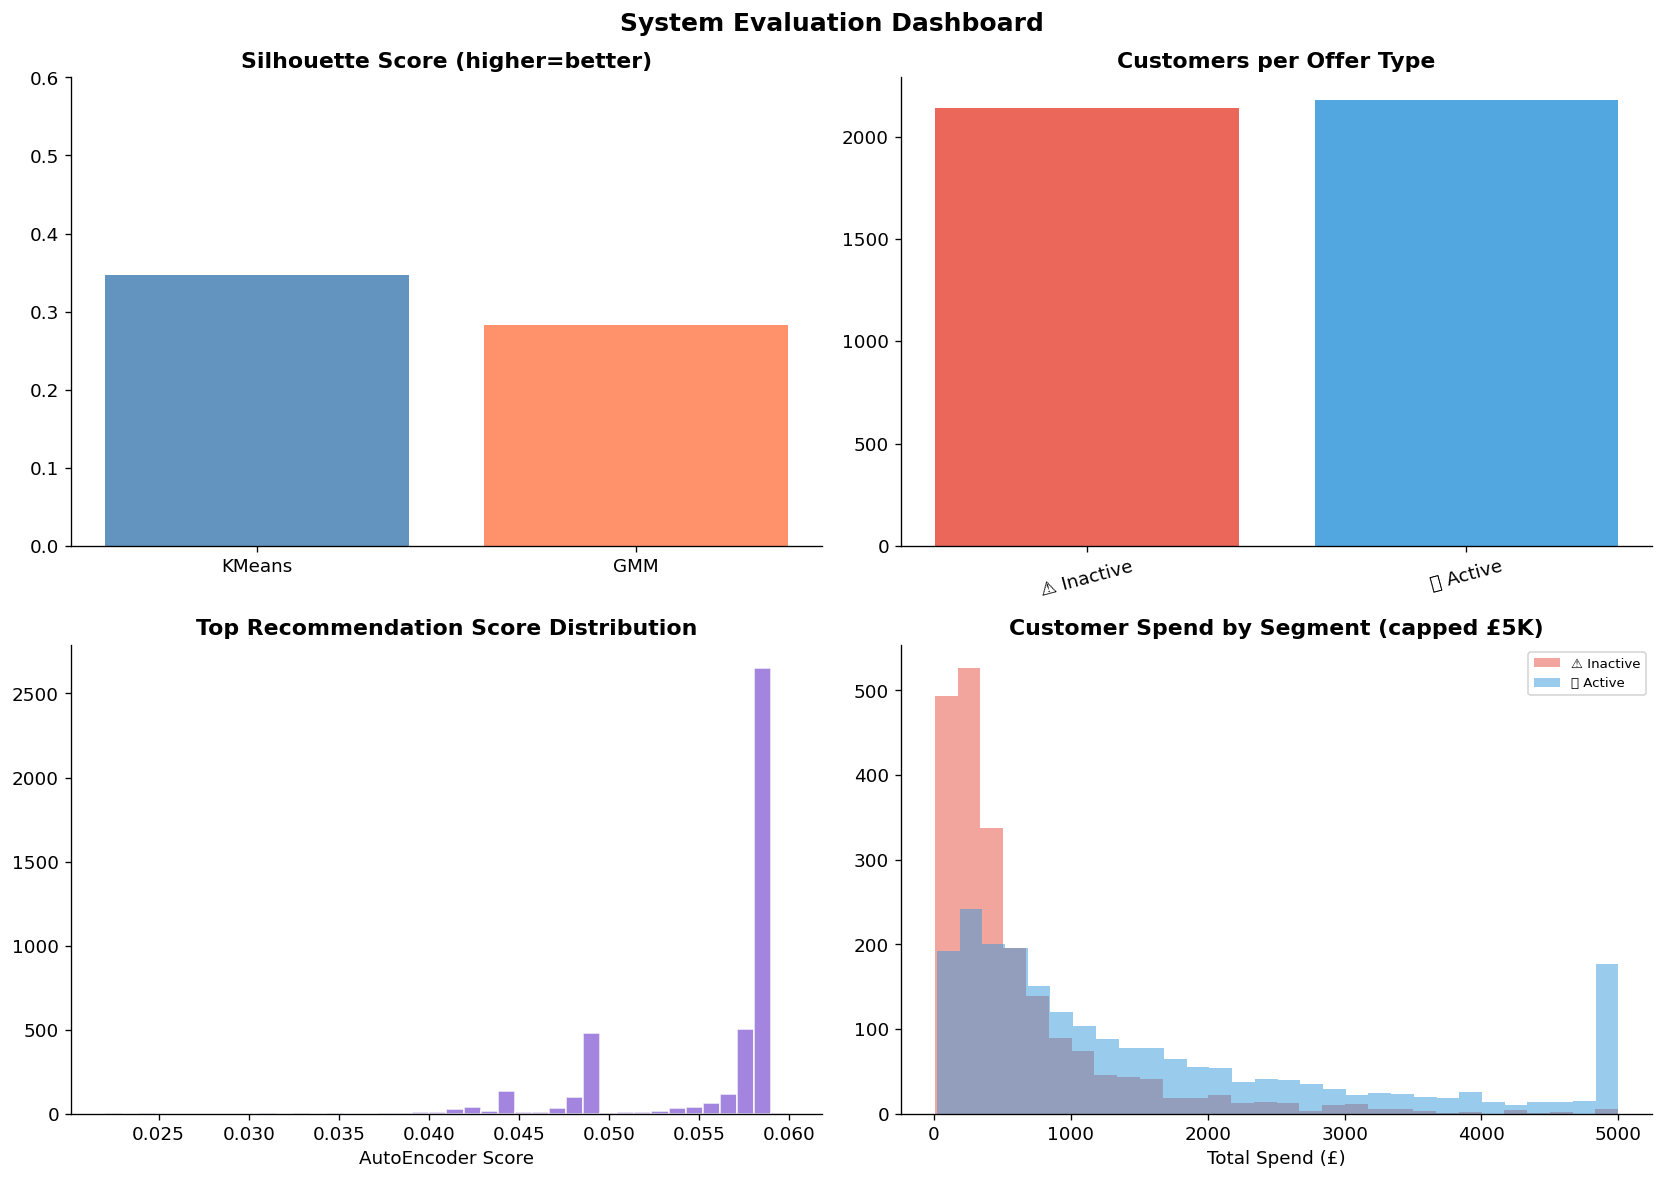

In [100]:
# ── 8.4  Final evaluation dashboard ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Silhouette comparison
axes[0,0].bar(['KMeans','GMM'], [km_final_sil, gmm_final_sil],
               color=['steelblue','coral'], alpha=0.85)
axes[0,0].set_title('Silhouette Score (higher=better)', fontweight='bold')
axes[0,0].set_ylim(0, 0.6)

# Offer discount distribution
disc_counts = offers_df.groupby(['Segment','Discount_Pct']).size().reset_index()
for i,(seg, grp) in enumerate(offers_df.groupby('Segment')):
    axes[0,1].bar(seg, len(grp), color=PALETTE[i], alpha=0.85)
axes[0,1].set_title('Customers per Offer Type', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=15)

# Reconstruction score distribution
rec_scores = [recs[0]['Score'] for recs in recommendations.values() if recs]
axes[1,0].hist(rec_scores, bins=40, color='mediumpurple', alpha=0.85, edgecolor='white')
axes[1,0].set_title('Top Recommendation Score Distribution', fontweight='bold')
axes[1,0].set_xlabel('AutoEncoder Score')

# Monetary distribution by segment
for i, (seg, grp) in enumerate(offers_df.groupby('Segment')):
    axes[1,1].hist(grp['Monetary'].clip(upper=5000), bins=30, alpha=0.5,
                   label=seg, color=PALETTE[i])
axes[1,1].set_title('Customer Spend by Segment (capped £5K)', fontweight='bold')
axes[1,1].set_xlabel('Total Spend (£)')
axes[1,1].legend(fontsize=8)

plt.suptitle('System Evaluation Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💾 Step 9 — Export Results

In [101]:
# ── Save customer offers ───────────────────────────────────────
export_cols = [
    'CustomerID','Segment','Segment_Source','GMM_Confidence',
    'Discount_Pct','Recommended_Product',
    'All_Recommendations','Message',
    'Recency','Frequency','Monetary'
]
offers_df[export_cols].to_csv('customer_offers.csv', index=False)
print('✅ customer_offers.csv saved')

# Save full RFM with cluster labels
rfm_export = rfm[[
    'CustomerID','Recency','Frequency','Monetary',
    'AvgOrderValue','UniqueProducts',
    'KMeans_Cluster','Segment','GMM_Cluster','GMM_MaxProb'
]]
rfm_export.to_csv('customer_rfm_segments.csv', index=False)
print('✅ customer_rfm_segments.csv saved')

✅ customer_offers.csv saved
✅ customer_rfm_segments.csv saved


In [102]:
# ── Final pipeline summary ─────────────────────────────────────
print('=' * 65)
print('🏁  PIPELINE SUMMARY')
print('=' * 65)
print(f'  Raw transactions        : 541,909')
print(f'  Clean transactions      : {len(df):,}')
print(f'  Customers analysed      : {len(rfm):,}')
print(f'  Products in model       : {n_products_ae:,}')
print()
print('  SEGMENTATION')
for seg, grp in offers_df.groupby('Segment'):
    d = OFFER_TEMPLATES.get(seg, {}).get('discount_pct', '?')
    print(f'    {seg:<22}: {len(grp):>4,} customers  →  {d}% discount')
print()
print('  RECOMMENDATION ENGINE')
print(f'    User coverage           : {user_coverage:.1%}')
print(f'    Catalog coverage        : {catalog_coverage:.1%}')
print(f'    AutoEncoder val loss    : {min(history.history["val_loss"]):.6f}')
print()
print('  OFFERS GENERATED        :', len(offers_df))
print('  Borderline (GMM-blended):', (offers_df['Segment_Source']=='GMM-blended (borderline)').sum())
print('=' * 65)

🏁  PIPELINE SUMMARY
  Raw transactions        : 541,909
  Clean transactions      : 396,501
  Customers analysed      : 4,320
  Products in model       : 3,665

  SEGMENTATION
    ⚠️ Inactive           : 2,139 customers  →  20% discount
    🟢 Active              : 2,181 customers  →  10% discount

  RECOMMENDATION ENGINE
    User coverage           : 100.0%
    Catalog coverage        : 1.1%
    AutoEncoder val loss    : 0.003395

  OFFERS GENERATED        : 4320
  Borderline (GMM-blended): 0


In [103]:
offers_df.to_csv("customer_offers.csv", index=False)

rfm.to_csv("customer_segments.csv", index=False)